# Getting Started with FinDiff 

Welcome to **FinDiff**, a conditional diffusion model for generating high-quality synthetic tabular data (especially tailored for financial datasets).

In this tutorial, we will cover the following steps:
1. Prepare the tabular data for training.
2. Transform the data using speical `DataTransformer`.
3. Initialize and train the `FinDiff` diffusion model.
4. Generate new synthetic tabular data.
5. Evaluate the synthetic data quality.

First, let's install the required libraries.

In [1]:
# # install required libraries
!pip3 install sdv # install the synthetic data vault library
!pip3 install -U ucimlrepo 
!pip3 install requests seaborn 
!pip3 install nbformat


[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


Import required libraries.

In [2]:
# import data science libraries
import numpy as np

# import pytorch libraries
import torch
from torch.utils.data import DataLoader

# import synthetic data vault libraries
from sdv.metadata import SingleTableMetadata
import sdv.evaluation.single_table as sdv_st
from sdmetrics.visualization import get_column_plot

# import visualisation libraries
import matplotlib.pyplot as plt

from ucimlrepo import fetch_ucirepo

# ipython reload extension for auto-reloading modules
%load_ext autoreload
%autoreload 2

In [3]:
import sys
import os

# Get the absolute path to the project root directory
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))

# Add the path to sys.path if it's not already there
if project_root not in sys.path:
    sys.path.append(project_root)

# Now you can import findiff
from findiff import DataTransformer, FinDiff, FinDiffDataset


### Experiment Configuration Protocol

This section defines and initializes all hyperparameters, architectural layouts, and environmental controls for the machine learning pipeline. 

* **General System Settings**
  * Controls deterministic reproducibility via global random seed initialization.
  * Dynamically detects hardware availability to assign processing workloads to either CPU or CUDA devices.

* **Data Preprocessing & Encoding Settings**
  * **Categorical Encoding:** Defines the mathematical mapping of discrete categories into a continuous embedding space *(Note: Currently supports `label_encoder` only)*.
  * **Categorical Decoding:** Evaluates the reconstruction methodology to translate latent embeddings back into original categories.
    * **Distance-based (`distance`):** Employs a Nearest-Neighbor lookup to identify the closest valid embedding vector by calculating geometric distance.
    * **Logits-based (`logits`):** Utilizes raw prediction outputs mapped against a probability distribution over a one-hot vector for each category.
  * **Numerical Scaling:** Standardizes continuous features to optimize gradient flow and convergence stability.

* **Neural Network Architecture**
  * Configures the structural backbone (`mlp`, `unet`, or `transformer`), layer dimensions, residual capacity, and activation functions for the underlying neural model.

* **Diffusion Hyperparameters**
  * Isolates generative settings tailored for the diffusion synthesizer, including time-step discretization, embedding dimensionality, and variance schedule constraints ($\beta_{\text{start}}$ to $\beta_{\text{end}}$).

* **Training Loop Parameters**
  * Dictates standard optimization constraints including dataset iteration caps (epochs), batch normalization sizes, and learning rate boundaries.


In [4]:
# ==============================================================================
# 1. EXPERIMENT CONFIGURATION
# ==============================================================================
config = {
    # --- General System Settings ---
    "seed": 1234,
    "device": torch.device("cuda:0" if torch.cuda.is_available() else "cpu").type,

    # --- Data Preprocessing Settings ---
    # 'label_encoder': Maps categories to embedding space (currently only option supported)
    "cat_encoding": "label_encoder", 
    # 'distance': Uses nearest-neighbor lookup | 'logits': Uses one-hot vectors
    "cat_decoding": "distance",       
    "num_scaling": "standard",

    # --- Neural Network Architecture ---
    "backbone_type": "mlp",            # Options: 'unet', 'mlp', 'transformer'
    "cat_emb_dim": 2,                  # Dimension of categorical embeddings
    "mlp_hidden_dim": 512,             # Number of neurons per layer
    "mlp_num_residual_blocks": 2,      # Number of residual blocks for MLP
    "activation": "lrelu",             # Non-linear activation function

    # --- Diffusion Hyperparameters ---
    "diffusion_steps": 500,            # Lower steps used for fast tutorial demonstration
    "diffusion_beta_start": 1e-4,      # Initial noise schedule value
    "diffusion_beta_end": 0.02,        # Final noise schedule value
    "scheduler": "linear",             # Type of noise schedule
    "timestep_emb_dim": 64,            # Dimension of the timestep embedding
    "emb_learnable": False,            # Toggle to learn or freeze categorical embeddings

    # --- Training Loop Parameters ---
    "epochs": 500,                      
    "batch_size": 512,                 
    "learning_rate": 1e-4              
}

# ==============================================================================
# 2. ENVIRONMENT INITIALIZATION
# ==============================================================================
# Example usage: print active device to confirm setup
print(f"Experiment initialized using device: {config['device'].upper()}")


Experiment initialized using device: CPU


Set random seed values.

In [5]:
# set numpy seed
np.random.seed(config["seed"])

if config["device"] == "cuda":
    # set pytorch seed
    torch.manual_seed(config["seed"])

    # set cuda seed
    torch.cuda.manual_seed(config["seed"])

## 1. Data Preparation

For this tutorial, we will use the **Default of Credit Card Clients** dataset from the UCI Machine Learning Repository. This tabular dataset captures demographic factors, history of past monthly payments, and bill statements of credit card clients in Taiwan. It serves as a good benchmark for validating our tabular generative model (**FinDiff**), as it contains a mix of categorical values (e.g., gender, education) and continuous numerical values (e.g., credit limit, bill amounts).

* **Dataset Source:** [UCI Credit Card Dataset](https://uci.edu)
* **Dimensions:** 30,000 instances across 23 features
* **Target:** Binary classification indicator for payment default

### Programmatic Data Acquisition
We can load the features \(X\) and targets \(y\) directly into Pandas DataFrame using the official repository utility:

In [6]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
default_of_credit_card_clients = fetch_ucirepo(id=350)

# data (as pandas dataframes)
X = default_of_credit_card_clients.data.features
y = default_of_credit_card_clients.data.targets

# map X column names to variable names
cols = default_of_credit_card_clients.variables
X.columns = cols[cols["name"].isin(X.columns)]["description"].to_list()
original_data = X.copy()

Inspect the top 10 rows and attribute names of the dataset retreived.

In [7]:
# display top 10 rows
original_data.head(10)

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
0,20000,2,2,1,24,2,2,-1,-1,-2,...,689,0,0,0,0,689,0,0,0,0
1,120000,2,2,2,26,-1,2,0,0,0,...,2682,3272,3455,3261,0,1000,1000,1000,0,2000
2,90000,2,2,2,34,0,0,0,0,0,...,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000
3,50000,2,2,1,37,0,0,0,0,0,...,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000
4,50000,1,2,1,57,-1,0,-1,0,0,...,35835,20940,19146,19131,2000,36681,10000,9000,689,679
5,50000,1,1,2,37,0,0,0,0,0,...,57608,19394,19619,20024,2500,1815,657,1000,1000,800
6,500000,1,1,2,29,0,0,0,0,0,...,445007,542653,483003,473944,55000,40000,38000,20239,13750,13770
7,100000,2,2,2,23,0,-1,-1,0,0,...,601,221,-159,567,380,601,0,581,1687,1542
8,140000,2,3,1,28,0,0,2,0,0,...,12108,12211,11793,3719,3329,0,432,1000,1000,1000
9,20000,1,3,2,35,-2,-2,-2,-2,-1,...,0,0,13007,13912,0,0,0,13007,1122,0


Set numerical and categorical dataset attributes. 

In [8]:
# determine categorical attributes
cat_attrs = [
    "SEX",
    "EDUCATION",
    "MARRIAGE",
    "AGE",
    "PAY_0",
    "PAY_2",
    "PAY_3",
    "PAY_4",
    "PAY_5",
    "PAY_6",
]

# determine numerical attributes
num_attrs = [
    "LIMIT_BAL",
    "BILL_AMT1",
    "BILL_AMT2",
    "BILL_AMT3",
    "BILL_AMT4",
    "BILL_AMT5",
    "BILL_AMT6",
    "PAY_AMT1",
    "PAY_AMT2",
    "PAY_AMT3",
    "PAY_AMT4",
    "PAY_AMT5",
    "PAY_AMT6",
]
# convert categorical attributes to string
original_data[cat_attrs] = original_data[cat_attrs].astype(str)
# convert numerical attributes to float
original_data[num_attrs] = original_data[num_attrs].astype(float)

## 2. Data Transformation with `DataTransformer`

The `DataTransformer` class in FinDiff bridges the gap between raw tabular datasets (like pandas DataFrames) and the tensor formats required by the diffusion neural networks. It handles the preprocessing, scaling, and encoding of mixed-type data, as well as the reconstruction back to the original tabular format.

### Main Components & Features

1. **Explicit Column Definitions**: Unlike some auto-ML tools, `DataTransformer` does not infer data types automatically. You must explicitly provide the lists of categorical (`categorical_cols`) and numerical (`numerical_cols`) column names.
2. **Numerical Scaling**: It supports multiple scaling strategies for continuous features. You can specify `numerical_scaler` as `"standard"`, `"minmax"`, `"robust"`, `"power"` (Yeo-Johnson), or `"quantile"`.
3. **Categorical Encoding**: Categorical columns are ordinal-encoded using `LabelEncoder`. To prevent category collisions across different columns (e.g., a category "None" in two different columns), the transformer automatically prepends the column name to each category value before encoding.
4. **Conditional Label Encoding**: If you are using conditional generation, the transformer can optionally fit and encode a target label (`y`), mapping unseen labels to `-1`.

### Data Formats

* **Input (`fit` / `transform`)**: Expects a `pandas.DataFrame` for the features (`X`) and an optional `pandas.Series` for the labels (`y`).
* **Output (`transform`)**: Returns a dictionary of PyTorch-ready `numpy.ndarray`s with the keys:
  * `"num"`: Scaled numerical features.
  * `"cat"`: Encoded categorical features.
  * `"label"`: (Optional) Encoded target labels.
* **Output (`inverse_transform`)**: Takes the dictionary of arrays generated by the model and reconstructs a `pandas.DataFrame` with the original categorical strings and unscaled numerical values.

In [9]:
# init data FinDiff data transformer
data_transformer = DataTransformer(categorical_cols=cat_attrs, numerical_cols=num_attrs)

# fit and transform train dataset
data_transformer.fit(X=original_data, y=y)
original_data_scaled = data_transformer.transform(X=original_data, y=y)

# convert training data and labels to tensors
X_train_cat = torch.LongTensor(original_data_scaled["cat"].astype(np.int32))
X_train_num = torch.FloatTensor(original_data_scaled["num"].astype(np.float32))
y_train_torch = torch.LongTensor(original_data_scaled["label"].astype(np.int32))

# init fedtabdiff dataset
train_set = FinDiffDataset(
    cat_dataset=X_train_cat, num_dataset=X_train_num, labels=y_train_torch
)
# init the training data loader
train_dataloader = DataLoader(dataset=train_set, batch_size=config["batch_size"], shuffle=True)

## 3. Initializing and Training the Model
Instantiate the `FinDiff` model using our defined configuration settings, passing in our fitted `DataTransformer`. The model automatically extracts the vocabulary sizes and column counts it needs to build its neural network backbone. The class encapsulates data transformation, conditioning architectures, noise schedules, and the training loop controls.

In [10]:
# ==============================================================================
# 3. INITIALIZE FINDIFF SYNTHESIZER
# ==============================================================================
findiff_model = FinDiff(
    # --- Data Pipeline Integration ---
    data_transformer=data_transformer,       # Transformer instance holding metadata and feature scalers
    cat_emb_dim=config["cat_emb_dim"],       # Dimensionality size allocated for each categorical variable
    emb_learnable=config["emb_learnable"],   # True = train embeddings jointly | False = freeze initial mappings

    # --- Generative Diffusion Schedule ---
    diffusion_total_steps=config["diffusion_steps"],   # Total forward/backward steps (T) for the diffusion process
    diffusion_scheduler=config["scheduler"],           # Type of noise addition schedule (e.g., 'linear' or 'cosine')
    diffusion_beta_start=config["diffusion_beta_start"], # Lower variance boundary for initial diffusion timestep
    diffusion_beta_end=config["diffusion_beta_end"],     # Upper variance boundary for final diffusion timestep

    # --- Neural Network Backbone Architecture ---
    backbone_type=config["backbone_type"],   # The underlying network structure (e.g., 'mlp', 'unet')
    timestep_emb_dim=config["timestep_emb_dim"], # Dimensionality for projectable time embeddings
    backbone_config={
        "mlp_num_residual_blocks": config["mlp_num_residual_blocks"], # Model depth (number of skip-connection blocks)
        "mlp_hidden_dim": config["mlp_hidden_dim"],                 # Model width (neurons per dense layer)
    },

    # --- Optimization & Environment Controls ---
    learning_rate=config["learning_rate"],   # Step size for the Adam/AdamW optimizer during backpropagation
    num_epochs=config["epochs"],             # Full iterations over the prepared training dataset
    batch_size=config["batch_size"],         # Sample size processed concurrently before gradient updates
    device=config["device"],                 # Compute target hardware acceleration destination ('cuda' or 'cpu')
)

print("FinDiff model successfully initialized and mapped to device allocations.")


FinDiff model successfully initialized and mapped to device allocations.


In [11]:
findiff_model.fit(train_dataloader)

Epoch 0500 | Train Loss: 4.560054: 100%|██████████| 500/500 [04:40<00:00,  1.78it/s]


### Visualize training loss progression.

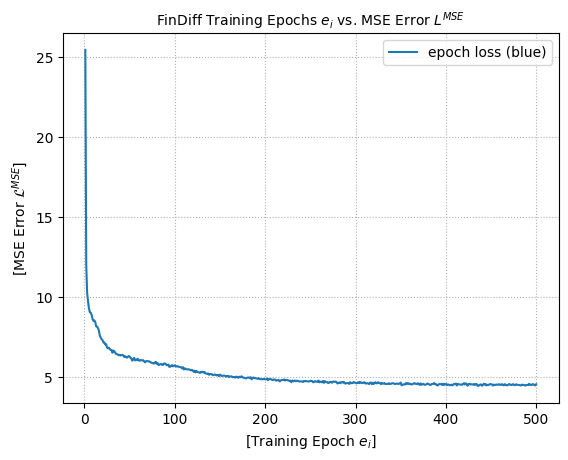

In [12]:
train_loss = findiff_model.training_history["train_loss"]
# prepare plot
fig = plt.figure()
ax = fig.add_subplot(111)

# add grid
ax.grid(linestyle="dotted")

# plot the training epochs vs. the epochs' classification error
ax.plot(np.array(range(1, len(train_loss) + 1)), train_loss, label="epoch loss (blue)")

# add axis legends
ax.set_xlabel("[Training Epoch $e_i$]", fontsize=10)
ax.set_ylabel("[MSE Error $\mathcal{L}^{MSE}$]", fontsize=10)

# set plot legend
plt.legend(loc="upper right", numpoints=1, fancybox=True)

# add plot title
plt.title("FinDiff Training Epochs $e_i$ vs. MSE Error $L^{MSE}$", fontsize=10);

## 4. Generating Synthetic Data
Once trained, generating synthetic tabular records is as simple as calling `.sample()`. The model automatically reverses the diffusion process, decodes the outputs, and reconstructs a pandas DataFrame with your original column names and text categories!

In [13]:
synt_dataset = findiff_model.sample(label=y_train_torch)
synt_dataset.head()

,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,...,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
0,2,2,1,22,0,0,2,-1,2,2,...,24160.150391,17531.007812,19610.107422,17829.892578,4120.284180,382.965332,774.116211,1258.280029,850.267334,3824.096924
1,1,2,2,55,-1,-1,0,0,0,0,...,7364.796875,10111.000000,12630.291016,8961.767578,2125.925781,4032.334229,2419.157715,2610.266113,1759.081055,16990.939453
2,1,5,2,52,1,-1,0,0,2,2,...,2629.792969,-1540.714844,-6459.183594,1706.371094,1314.455566,135.842773,633.186523,373.619629,947.329102,406.564941
3,2,1,2,23,0,0,0,0,0,0,...,3631.449219,10199.667969,11515.281250,15393.429688,1634.357910,1115.472168,2279.696045,2181.310547,2936.837891,2201.009277
4,2,2,2,39,0,0,0,0,0,0,...,157546.593750,204353.312500,105965.125000,102221.882812,6411.121094,14175.146484,45910.031250,4658.509766,14160.323242,3384.841797


Compare it with original data and evaluate.

In [14]:
original_data.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
0,20000.0,2,2,1,24,2,2,-1,-1,-2,...,689.0,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0
1,120000.0,2,2,2,26,-1,2,0,0,0,...,2682.0,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0
2,90000.0,2,2,2,34,0,0,0,0,0,...,13559.0,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0
3,50000.0,2,2,1,37,0,0,0,0,0,...,49291.0,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0
4,50000.0,1,2,1,57,-1,0,-1,0,0,...,35835.0,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0


## 5. Evaluating the Generated Data
We can use the `sdv` library to evaluate how closely our synthetic dataset matches the original.

In [15]:
# build a metadata for evaluation (from SDV)
metadata = SingleTableMetadata()
metadata.detect_from_dataframe(data=original_data)

# generate quality report
quality_report = sdv_st.evaluate_quality(
    real_data=original_data, synthetic_data=synt_dataset, metadata=metadata
)

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 23/23 [00:00<00:00, 90.01it/s]| 
Column Shapes Score: 90.86%

(2/2) Evaluating Column Pair Trends: |██████████| 253/253 [00:01<00:00, 209.42it/s]|
Column Pair Trends Score: 92.52%

Overall Score (Average): 91.69%



### Visualizing Feature Fidelity

To assess the quality of the generated tabular data, we compare the distributions of individual columns between our real training dataset and the generated synthetic output. 

The cell below plots a distribution comparison (`distplot`) for the continuous numerical column **`PAY_AMT2`** (Payment Amount 2) to evaluate how well FinDiff has learned the underlying shape, density, and skewness of the original data.


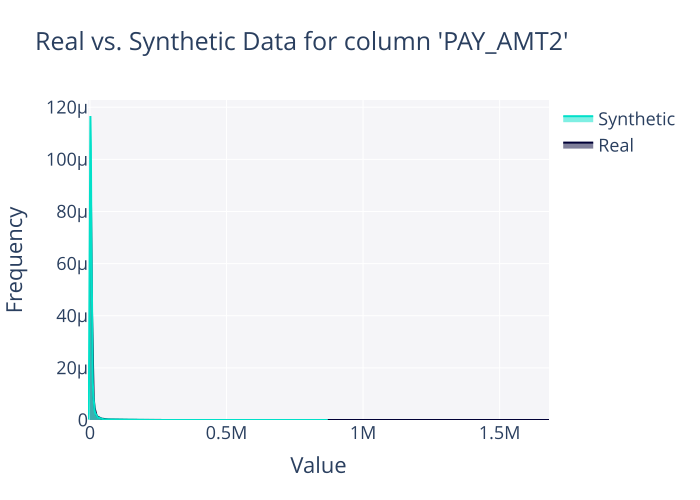

In [16]:
fig = get_column_plot(
    real_data=original_data,
    synthetic_data=synt_dataset,
    column_name="PAY_AMT2",
    plot_type="distplot",
)

fig.show(renderer="svg")


### Visualizing Categorical Value Fidelity

While numerical columns check for shape and skewness, categorical columns evaluate the model's ability to capture discrete probability distributions. 

The cell below generates a comparative bar chart (`bar`) for the **`EDUCATION`** column. This plot reveals how accurately FinDiff reproduces the relative frequencies, proportions, and presence of discrete categories compared to the original dataset.


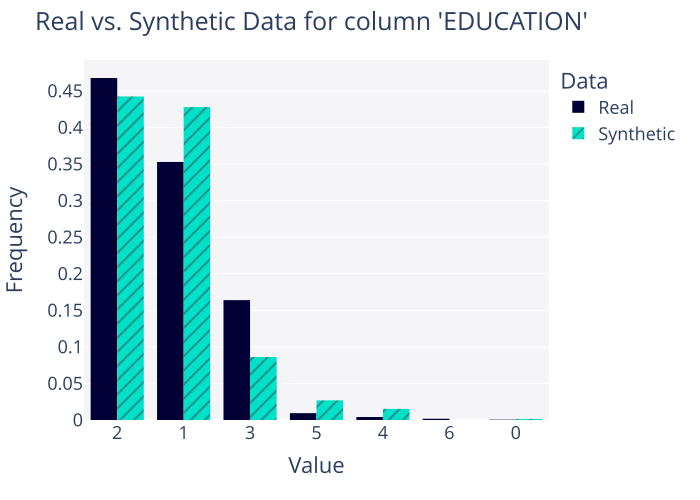

In [17]:
fig = get_column_plot(
    real_data=original_data,
    synthetic_data=synt_dataset,
    column_name="EDUCATION",
    plot_type="bar",
)

fig.show(renderer="svg")


### Global Column Shapes Evaluation

To quantify the model's performance globally across all features, we evaluate the overall statistical similarity between the real and synthetic columns. 

The cell below extracts the **"Column Shapes"** visualization from our evaluation suite. This plot directly corresponds to the **"Fidelity Column"** metrics discussed in the FinDiff paper, aggregating the shape similarity scores across all individual numerical and categorical attributes to provide a high-level view of generation fidelity.


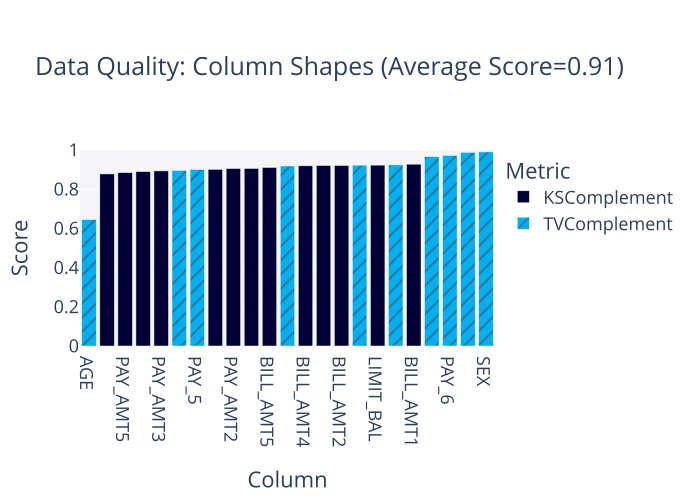

In [18]:
# plot Column Shapes -> referred to the "Fidelity Column" in the paper
fig = quality_report.get_visualization(property_name="Column Shapes")
fig.show(renderer="svg")

### Global Column Pair Trends Evaluation

While individual column shapes verify marginal distributions, evaluating column pairs measures the model's capacity to preserve complex cross-feature dependencies, correlations, and interactions.

The cell below extracts the **"Column Pair Trends"** visualization from our evaluation suite. This plot directly corresponds to the **"Fidelity Row"** metrics discussed in the FinDiff paper, summarizing how accurately the model captures correlations between all pairs of features relative to the ground truth.


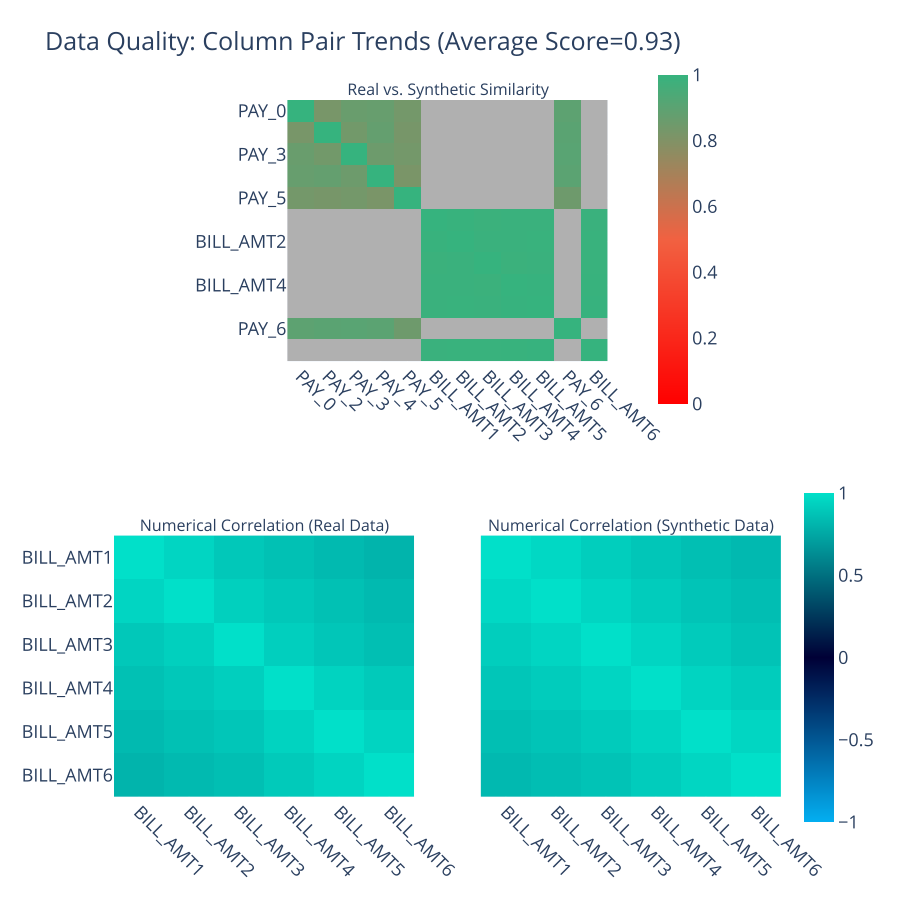

In [19]:
# plot Column Pair Trends -> referred to the "Fidelity Row" in the paper
fig = quality_report.get_visualization(property_name="Column Pair Trends")
fig.show(renderer="svg")